# 糖尿病預測優化版：以篩檢任務為核心的機器學習流程

本 notebook 是原始 `GA-XGBoost + Stacking` 專案的優化實驗版，重點不只是追求最高 ROC-AUC，而是更貼近糖尿病早期篩檢情境。

## 本版包含四個優化

1. **重新定義主要評估目標**：加入 PR-AUC、F2、Sensitivity、Specificity、混淆矩陣與 threshold-based 評估。
2. **Threshold tuning**：不再固定使用 0.5，改用 validation set 搜尋符合篩檢需求的最佳閾值。
3. **修正 SMOTE + CV 驗證邏輯**：使用 `imblearn.pipeline.Pipeline`，讓 SMOTE 只在每個 CV fold 的訓練資料內發生，避免資料洩漏與過度樂觀。
4. **比較不平衡策略並用任務導向選模**：比較 baseline、class weight、scale_pos_weight、SMOTE、SMOTE + threshold tuning，最後用篩檢規則選出推薦模型。


## 1. 匯入套件與全域設定

In [1]:
import os
import glob
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC, BorderlineSMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay,
)

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print('環境載入完成')
print('XGBoost:', xgb.__version__)
print('LightGBM:', lgb.__version__)

環境載入完成
XGBoost: 2.1.4
LightGBM: 4.6.0


## 2. 載入資料

流程會優先尋找本地資料，若找不到，才透過 `kagglehub` 下載 Kaggle 的 CDC BRFSS 2015 糖尿病資料集。

In [2]:
TARGET_FILENAME = 'diabetes_binary_health_indicators_BRFSS2015.csv'
LOCAL_DATA_DIRS = ['./data', '.', '../data']

df = None
csv_path = None

for data_dir in LOCAL_DATA_DIRS:
    candidates = glob.glob(os.path.join(data_dir, '**', TARGET_FILENAME), recursive=True)
    if candidates:
        csv_path = candidates[0]
        break

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'使用本地資料：{csv_path}')
else:
    print('找不到本地 CSV，改用 kagglehub 下載資料...')
    import kagglehub
    dataset_dir = kagglehub.dataset_download('alexteboul/diabetes-health-indicators-dataset')
    csv_path = os.path.join(dataset_dir, TARGET_FILENAME)
    df = pd.read_csv(csv_path)
    print(f'使用 KaggleHub 資料：{csv_path}')

print('資料維度：', df.shape)
display(df.head())

找不到本地 CSV，改用 kagglehub 下載資料...
使用 KaggleHub 資料：C:\Users\ahd31\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1\diabetes_binary_health_indicators_BRFSS2015.csv
資料維度： (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. 基礎資料檢查與欄位設定

In [3]:
target = 'Diabetes_binary'
features = [col for col in df.columns if col != target]

binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]
ordinal_features = ['GenHlth', 'Age', 'Education', 'Income']
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

print('缺失值總數：', int(df.isna().sum().sum()))
print('重複列數：', int(df.duplicated().sum()))
print('類別比例：')
display(df[target].value_counts(normalize=True).rename('ratio').to_frame())

X = df[features].copy()
y = df[target].astype(int).copy()

缺失值總數： 0
重複列數： 24206
類別比例：


,ratio
Diabetes_binary,
0.0,0.860667
1.0,0.139333


## 4. Train / Validation / Test 切分

這裡使用三段切分：

- **Train**：訓練模型與交叉驗證。
- **Validation**：專門做 threshold tuning。
- **Test**：最後一次評估，保持原始類別比例，不做 SMOTE。

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_full
)

split_summary = pd.DataFrame({
    '資料集': ['Train', 'Validation', 'Test'],
    '筆數': [len(y_train), len(y_val), len(y_test)],
    '糖尿病比例': [y_train.mean(), y_val.mean(), y_test.mean()],
})
display(split_summary)

,資料集,筆數,糖尿病比例
0,Train,162355,0.139337
1,Validation,40589,0.139323
2,Test,50736,0.139329


## 5. 評估函式：加入篩檢情境指標

糖尿病早期篩檢通常比一般分類更重視 Recall / Sensitivity，因為漏診的成本高於誤報。這裡加入：

- **Sensitivity / Recall**：實際糖尿病者被抓出的比例。
- **Specificity**：非糖尿病者被正確排除的比例。
- **PR-AUC**：不平衡資料比 ROC-AUC 更敏感。
- **F2**：比 F1 更重視 Recall。

In [5]:
def metrics_at_threshold(y_true, y_proba, threshold=0.5, model_name='model', strategy='default'):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0
    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    return {
        'Model': model_name,
        'Strategy': strategy,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall/Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'F2': fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
    }


def find_best_threshold(y_true, y_proba, min_recall=0.75):
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    rows = []
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        f1 = 2 * p * r / (p + r) if (p + r) else 0
        f2 = 5 * p * r / (4 * p + r) if (4 * p + r) else 0
        rows.append({'threshold': t, 'precision': p, 'recall': r, 'f1': f1, 'f2': f2})
    threshold_df = pd.DataFrame(rows)
    feasible = threshold_df[threshold_df['recall'] >= min_recall]
    if len(feasible) > 0:
        selected = feasible.sort_values(['f2', 'precision'], ascending=False).iloc[0]
        rule = f'Recall >= {min_recall:.2f} 且 F2 最大'
    else:
        selected = threshold_df.sort_values('f2', ascending=False).iloc[0]
        rule = '無法達到最低 Recall，改採 F2 最大'
    return float(selected['threshold']), rule, threshold_df


def get_proba(model, X_data):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, 'decision_function'):
        score = model.decision_function(X_data)
        return (score - score.min()) / (score.max() - score.min())
    raise ValueError('模型需要 predict_proba 或 decision_function')

## 6. 建立模型與不平衡策略

這裡比較四類策略：

1. **不做重抽樣，只調模型權重**。
2. **XGBoost / LightGBM 使用 scale_pos_weight**。
3. **SMOTE 放進 Pipeline**，確保 CV 每個 fold 只對訓練部分做 SMOTE。
4. **SMOTENC**：因為資料大多是 binary / ordinal，比一般 SMOTE 更適合混合型欄位。

In [6]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count
print('scale_pos_weight:', round(scale_pos_weight, 3))

numeric_preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), continuous_features + ordinal_features + binary_features)],
    remainder='drop'
)

categorical_indices = [features.index(col) for col in binary_features + ordinal_features]

model_specs = [
    {
        'name': 'Logistic Regression',
        'strategy': 'class_weight=balanced',
        'model': SkPipeline([
            ('preprocess', numeric_preprocessor),
            ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
    },
    {
        'name': 'Random Forest',
        'strategy': 'class_weight=balanced_subsample',
        'model': RandomForestClassifier(
            n_estimators=250, max_depth=12, min_samples_leaf=10,
            class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
        ),
    },
    {
        'name': 'XGBoost',
        'strategy': 'scale_pos_weight',
        'model': xgb.XGBClassifier(
            n_estimators=250, max_depth=4, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
            scale_pos_weight=scale_pos_weight, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1
        ),
    },
    {
        'name': 'LightGBM',
        'strategy': 'scale_pos_weight',
        'model': lgb.LGBMClassifier(
            n_estimators=250, max_depth=7, learning_rate=0.05,
            num_leaves=31, scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        ),
    },
    {
        'name': 'XGBoost',
        'strategy': 'SMOTE in Pipeline',
        'model': ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('clf', xgb.XGBClassifier(
                n_estimators=250, max_depth=4, learning_rate=0.05,
                subsample=0.85, colsample_bytree=0.85, min_child_weight=3,
                eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
            )),
        ]),
    },
    {
        'name': 'LightGBM',
        'strategy': 'SMOTENC in Pipeline',
        'model': ImbPipeline([
            ('smotenc', SMOTENC(categorical_features=categorical_indices, random_state=RANDOM_STATE)),
            ('clf', lgb.LGBMClassifier(
                n_estimators=250, max_depth=7, learning_rate=0.05,
                num_leaves=31, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
            )),
        ]),
    },
]

scale_pos_weight: 6.177


## 7. 修正版交叉驗證：SMOTE 只在 fold 內發生

這段是本版最重要的方法論修正之一。若先對整個訓練集 SMOTE 再 cross-validation，合成樣本可能把鄰近資訊帶進 validation fold，造成 CV 分數異常偏高。使用 Pipeline 後，每一折都會先切 train/validation，再只對該折 train 做重抽樣。

In [7]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
}

cv_rows = []
for spec in model_specs:
    print(f"CV 評估中：{spec['name']} - {spec['strategy']}")
    scores = cross_validate(
        spec['model'], X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1, error_score='raise'
    )
    cv_rows.append({
        'Model': spec['name'],
        'Strategy': spec['strategy'],
        'CV ROC-AUC': scores['test_roc_auc'].mean(),
        'CV PR-AUC': scores['test_pr_auc'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV F1': scores['test_f1'].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('CV PR-AUC', ascending=False).reset_index(drop=True)
display(cv_df)

CV 評估中：Logistic Regression - class_weight=balanced
CV 評估中：Random Forest - class_weight=balanced_subsample
CV 評估中：XGBoost - scale_pos_weight
CV 評估中：LightGBM - scale_pos_weight
CV 評估中：XGBoost - SMOTE in Pipeline
CV 評估中：LightGBM - SMOTENC in Pipeline


,Model,Strategy,CV ROC-AUC,CV PR-AUC,CV Recall,CV Precision,CV F1
0,XGBoost,scale_pos_weight,0.831578,0.435542,0.797100,0.308231,0.444550
1,LightGBM,scale_pos_weight,0.830433,0.433457,0.792768,0.307686,0.443310
2,Random Forest,class_weight=balanced_subsample,0.828741,0.429208,0.753956,0.323623,0.452856
3,XGBoost,SMOTE in Pipeline,0.824634,0.420752,0.267085,0.505382,0.349456
4,LightGBM,SMOTENC in Pipeline,0.818141,0.412187,0.400273,0.443201,0.420569
5,Logistic Regression,class_weight=balanced,0.823902,0.406508,0.766024,0.312682,0.444087


## 8. Validation threshold tuning

這裡每個模型都先在 Train 訓練，再到 Validation set 搜尋 threshold。預設規則是：

- 優先找到 **Recall >= 0.75** 的 threshold。
- 在可行 threshold 裡選 **F2 最大**者。
- 如果模型無法達到 Recall 0.75，則直接選 F2 最大。

In [8]:
MIN_RECALL_FOR_SCREENING = 0.75

fitted_models = []
validation_rows = []
threshold_curves = {}

for spec in model_specs:
    print(f"訓練與調 threshold：{spec['name']} - {spec['strategy']}")
    model = spec['model']
    model.fit(X_train, y_train)
    val_proba = get_proba(model, X_val)
    best_threshold, rule, curve_df = find_best_threshold(
        y_val, val_proba, min_recall=MIN_RECALL_FOR_SCREENING
    )
    validation_rows.append(metrics_at_threshold(
        y_val, val_proba, threshold=best_threshold,
        model_name=spec['name'], strategy=spec['strategy']
    ) | {'Threshold Rule': rule})
    fitted_models.append({
        **spec,
        'model': model,
        'best_threshold': best_threshold,
        'threshold_rule': rule,
    })
    threshold_curves[f"{spec['name']} | {spec['strategy']}"] = curve_df

val_df = pd.DataFrame(validation_rows).sort_values('F2', ascending=False).reset_index(drop=True)
display(val_df[['Model', 'Strategy', 'Threshold', 'Threshold Rule', 'Precision', 'Recall/Sensitivity', 'Specificity', 'F1', 'F2', 'ROC-AUC', 'PR-AUC']])

訓練與調 threshold：Logistic Regression - class_weight=balanced
訓練與調 threshold：Random Forest - class_weight=balanced_subsample
訓練與調 threshold：XGBoost - scale_pos_weight
訓練與調 threshold：LightGBM - scale_pos_weight
訓練與調 threshold：XGBoost - SMOTE in Pipeline
訓練與調 threshold：LightGBM - SMOTENC in Pipeline


,Model,Strategy,Threshold,Threshold Rule,Precision,Recall/Sensitivity,Specificity,F1,F2,ROC-AUC,PR-AUC
0,XGBoost,scale_pos_weight,0.463722,Recall >= 0.75 且 F2 最大,0.292827,0.821574,0.678823,0.431764,0.603596,0.828390,0.436506
1,Random Forest,class_weight=balanced_subsample,0.392797,Recall >= 0.75 且 F2 最大,0.271399,0.866844,0.623290,0.413374,0.602478,0.826358,0.430013
2,LightGBM,scale_pos_weight,0.452726,Recall >= 0.75 且 F2 最大,0.287766,0.829001,0.667859,0.427230,0.602400,0.827793,0.436643
3,Logistic Regression,class_weight=balanced,0.436061,Recall >= 0.75 且 F2 最大,0.287220,0.824226,0.668890,0.425993,0.599902,0.821236,0.403223
4,XGBoost,SMOTE in Pipeline,0.158251,Recall >= 0.75 且 F2 最大,0.280273,0.836605,0.652230,0.419880,0.598861,0.821316,0.417800
5,LightGBM,SMOTENC in Pipeline,0.188829,Recall >= 0.75 且 F2 最大,0.274443,0.838373,0.641209,0.413519,0.594185,0.816098,0.409196


## 9. Threshold curve 視覺化

觀察 Precision、Recall、F2 隨 threshold 的變化，可以更清楚解釋為什麼 0.5 不一定是適合醫療篩檢的閾值。

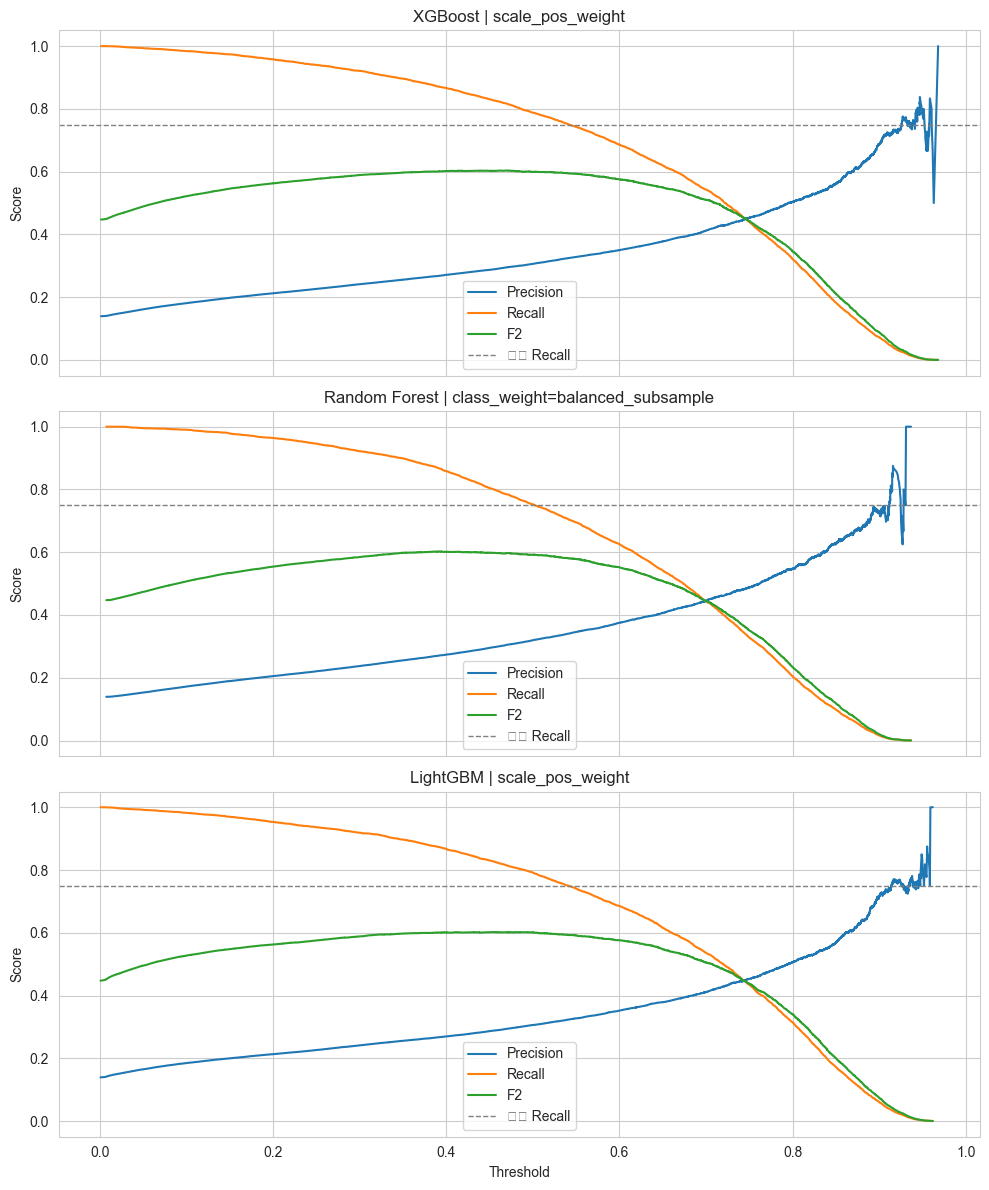

In [9]:
top_keys = val_df.head(3).apply(lambda r: f"{r['Model']} | {r['Strategy']}", axis=1).tolist()

fig, axes = plt.subplots(len(top_keys), 1, figsize=(10, 4 * len(top_keys)), sharex=True)
if len(top_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, top_keys):
    curve_df = threshold_curves[key]
    ax.plot(curve_df['threshold'], curve_df['precision'], label='Precision')
    ax.plot(curve_df['threshold'], curve_df['recall'], label='Recall')
    ax.plot(curve_df['threshold'], curve_df['f2'], label='F2')
    ax.axhline(MIN_RECALL_FOR_SCREENING, color='gray', linestyle='--', linewidth=1, label='目標 Recall')
    ax.set_title(key)
    ax.set_ylabel('Score')
    ax.legend(loc='best')

axes[-1].set_xlabel('Threshold')
plt.tight_layout()
plt.show()

## 10. Final test：用調好的 threshold 做最後評估

Test set 不參與任何 threshold tuning 或模型選擇，用來檢查模型在真實類別比例下的表現。

In [10]:
test_rows = []
for item in fitted_models:
    test_proba = get_proba(item['model'], X_test)
    test_rows.append(metrics_at_threshold(
        y_test, test_proba, threshold=item['best_threshold'],
        model_name=item['name'], strategy=item['strategy']
    ) | {'Threshold Rule': item['threshold_rule']})

test_df = pd.DataFrame(test_rows)
test_df = test_df.sort_values(['F2', 'Recall/Sensitivity', 'PR-AUC'], ascending=False).reset_index(drop=True)
display(test_df[['Model', 'Strategy', 'Threshold', 'Precision', 'Recall/Sensitivity', 'Specificity', 'F1', 'F2', 'ROC-AUC', 'PR-AUC', 'TP', 'FP', 'TN', 'FN']])

,Model,Strategy,Threshold,Precision,Recall/Sensitivity,Specificity,F1,F2,ROC-AUC,PR-AUC,TP,FP,TN,FN
0,XGBoost,scale_pos_weight,0.463722,0.292947,0.822606,0.678590,0.432037,0.604143,0.827044,0.423737,5815,14035,29632,1254
1,LightGBM,scale_pos_weight,0.452726,0.288046,0.831376,0.667346,0.427854,0.603648,0.826365,0.422160,5877,14526,29141,1192
2,Random Forest,class_weight=balanced_subsample,0.392797,0.270535,0.866601,0.621728,0.412345,0.601532,0.824040,0.416395,6126,16518,27149,943
3,Logistic Regression,class_weight=balanced,0.436061,0.287998,0.823172,0.670552,0.426707,0.600132,0.819692,0.392582,5819,14386,29281,1250
4,XGBoost,SMOTE in Pipeline,0.158251,0.280686,0.835903,0.653216,0.420255,0.598950,0.819337,0.408947,5909,15143,28524,1160
5,LightGBM,SMOTENC in Pipeline,0.188829,0.271826,0.830245,0.639957,0.409560,0.588465,0.814914,0.401956,5869,15722,27945,1200


## 11. 任務導向選模規則

原專案容易用 ROC-AUC 排第一的模型當 final model。本版改成更符合糖尿病篩檢情境的規則：

1. 先要求 Test Recall / Sensitivity >= 0.75。
2. 在符合條件者中選 F2 最高。
3. 若沒有模型達標，選 F2 最高，並明確註記「未達篩檢 Recall 目標」。

In [11]:
eligible = test_df[test_df['Recall/Sensitivity'] >= MIN_RECALL_FOR_SCREENING]
if len(eligible) > 0:
    recommended = eligible.sort_values(['F2', 'PR-AUC'], ascending=False).iloc[0]
    recommendation_note = '達成最低 Recall 目標，並在可行模型中 F2 最佳。'
else:
    recommended = test_df.sort_values(['F2', 'Recall/Sensitivity'], ascending=False).iloc[0]
    recommendation_note = '未達最低 Recall 目標，暫以 F2 最佳模型作為候選，需調整模型或閾值策略。'

print('推薦模型：')
print(f"模型：{recommended['Model']}")
print(f"不平衡策略：{recommended['Strategy']}")
print(f"Threshold：{recommended['Threshold']:.4f}")
print(f"Recall/Sensitivity：{recommended['Recall/Sensitivity']:.4f}")
print(f"Precision：{recommended['Precision']:.4f}")
print(f"Specificity：{recommended['Specificity']:.4f}")
print(f"F2：{recommended['F2']:.4f}")
print(f"PR-AUC：{recommended['PR-AUC']:.4f}")
print('說明：', recommendation_note)

推薦模型：
模型：XGBoost
不平衡策略：scale_pos_weight
Threshold：0.4637
Recall/Sensitivity：0.8226
Precision：0.2929
Specificity：0.6786
F2：0.6041
PR-AUC：0.4237
說明： 達成最低 Recall 目標，並在可行模型中 F2 最佳。


## 12. 混淆矩陣：推薦模型

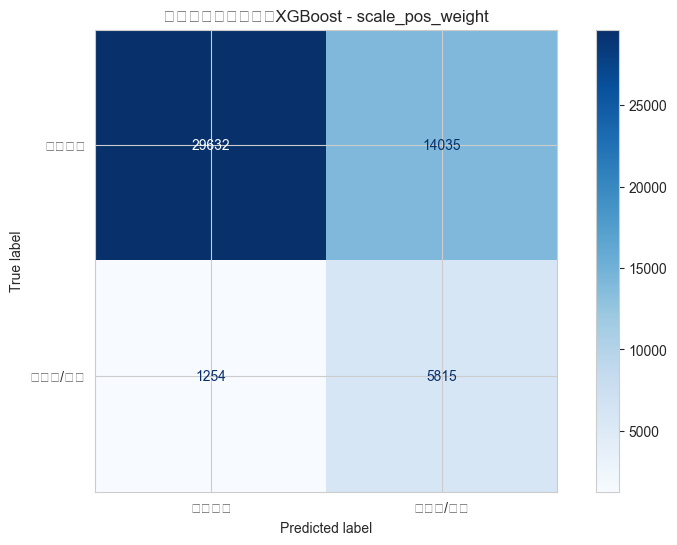

In [12]:
recommended_key = (recommended['Model'], recommended['Strategy'])
recommended_item = next(
    item for item in fitted_models
    if item['name'] == recommended_key[0] and item['strategy'] == recommended_key[1]
)
recommended_proba = get_proba(recommended_item['model'], X_test)
recommended_pred = (recommended_proba >= recommended_item['best_threshold']).astype(int)

cm = confusion_matrix(y_test, recommended_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['非糖尿病', '糖尿病/前期'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"推薦模型混淆矩陣：{recommended['Model']} - {recommended['Strategy']}")
plt.show()

## 13. ROC 與 Precision-Recall 曲線比較

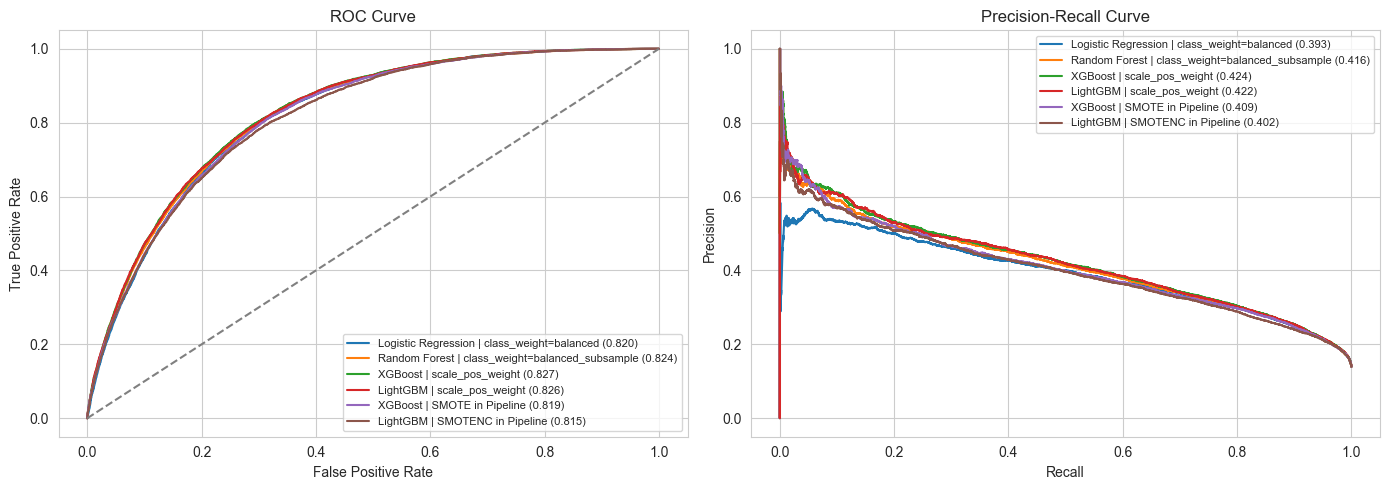

In [13]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for item in fitted_models:
    proba = get_proba(item['model'], X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{item['name']} | {item['strategy']} ({auc:.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for item in fitted_models:
    proba = get_proba(item['model'], X_test)
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{item['name']} | {item['strategy']} ({ap:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 14. 結論模板

執行完上方 cell 後，可以用以下角度撰寫報告：

1. 原本用 ROC-AUC 排名可能會偏好保守模型，但糖尿病篩檢需要優先降低漏診。
2. Threshold tuning 後，模型的 Recall / Precision trade-off 更透明，也能根據醫療任務調整決策點。
3. 使用 Pipeline 後，SMOTE 不會污染 validation fold，CV 分數更可信。
4. 若 `class_weight` 或 `scale_pos_weight` 表現接近 SMOTE，實務部署時可優先考慮，因為它們不會產生合成樣本。
5. 最終模型應由任務導向規則決定，例如 Recall 達標後再比較 F2、PR-AUC 與 Specificity，而不是單看 Accuracy 或 ROC-AUC。